# N-Body Simulations and Numerical Integrations with REBOUND

**Goal:** Learn how to simulate gravitational systems (stars, planets, etc.) using numerical integration.  
We will build a system step by step using [REBOUND](https://rebound.readthedocs.io/).


## What is Numerical Integration?

- Celestial bodies interact through **Newton’s law of gravitation**:

$$
\vec{F}_{ij}(r_{ij}) = -\,G\,\frac{m_i m_j}{|\vec{r}_{ij}|^3}\,\vec{r}_{ij}
$$

- This forms a set of **coupled differential equations** (the N-body problem).  
- Except for the simple 2-body case, **no analytic solutions exist** → we use numerical methods to step positions and velocities forward in time.


## Types of Numerical Integrators

| Integrator | Type        | Features |
|------------|--------------|-----------------------------------|
| **WHFast** | Symplectic    | Fast and stable for long-term systems (needs fixed timestep) |
| **IAS15**  | Adaptive      | Very accurate, handles close encounters, slower |

- **Symplectic** methods conserve energy well over long times but use fixed timesteps.
- **Adaptive** methods adjust timestep for accuracy, useful for eccentric/chaotic orbits.

For more: [**Integrators**](https://rebound.readthedocs.io/en/latest/integrators/)

## What Forces Are Included?

- By default, **REBOUND uses only Newtonian gravity** between massive bodies.
- All **massive particles** interact gravitationally with each other.
- **Massless particles** (test particles) feel the gravity of massive bodies, but do **not** affect anything themselves.
- This means our simulations are purely **Newtonian N-body systems** unless we explicitly add more physics.
- **Additional forces** (like general relativity, tides, or drag) are **not included by default**.  
  They can be added manually using the optional plugin library [**REBOUNDx**](https://reboundx.readthedocs.io/).


## Orbital Elements

We will use orbital elements to describe orbits as defined in [REBOUND’s orbital elements documentation](https://rebound.readthedocs.io/en/latest/orbitalelements/).

We track orbits using orbital elements including (but not limited to):

- **a** — semi-major axis (size)  
- **e** — eccentricity (shape)  
- **i** — inclination (tilt)  
- **Ω** — longitude of ascending node (horizontal orientation)  
- **ω** — argument of periastron (ellipse orientation)  
- **f** — true anomaly (current orbital position)

These are easier to interpret and compare than raw position/velocity values.

**Note 1:** In REBOUND you can also add particles directly using **Cartesian coordinates and velocities**  
(`x, y, z, vx, vy, vz`) — but we will not do that here.

**Note 2:** Some orbital elements can be used **instead of others**.  
For example, you can specify **orbital period (`P`)** instead of **semi-major axis (`a`)** —  
however, you **cannot give both at the same time**.  

REBOUND will compute the missing value from the one you provide using Kepler’s third law.


## REBOUND

[REBOUND](https://rebound.readthedocs.io/) is a modern, high-performance N-body integrator with Python bindings.

It allows us to:

- Define bodies by their orbital elements
- Choose integrators
- Step the system forward in time
- Extract orbital elements
- Plot orbits easily


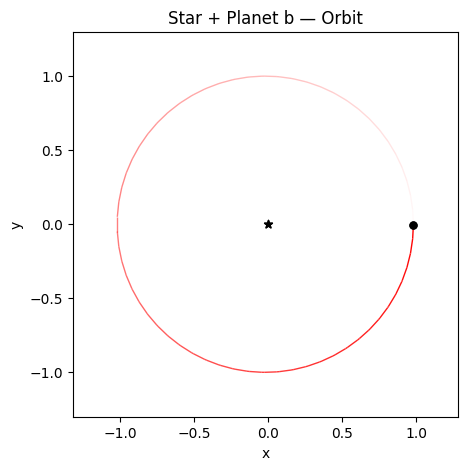

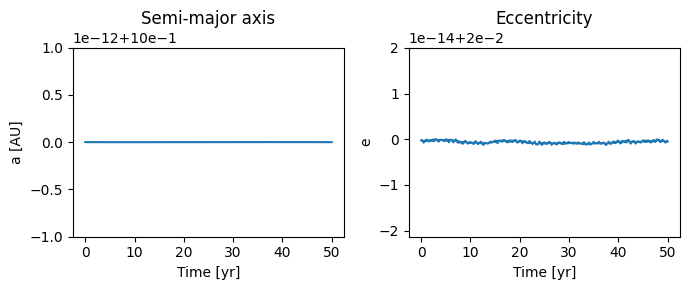

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

# Create simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add star and planet
sim.add(m=1.0)                   # star
sim.add(m=3e-6, a=1.0, e=0.02)    # planet b (~Earth-mass)
sim.move_to_com()

# Integrate and log orbital elements
# We will integrate for 50 yrs.
times = np.linspace(0, 50, 500)
a_vals, e_vals = [], []

for t in times:
    sim.integrate(t)
    o = sim.orbits()[0]
    a_vals.append(o.a)
    e_vals.append(o.e)

# Plot orbit in the x–y plane
fig = rebound.OrbitPlot(sim, color=True)
plt.title("Star + Planet b — Orbit")
plt.show()

# Plot orbital elements vs time
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.plot(times, a_vals)
plt.xlabel('Time [yr]'); plt.ylabel('a [AU]')
plt.title('Semi-major axis')
plt.subplot(1,2,2)
plt.plot(times, e_vals)
plt.xlabel('Time [yr]'); plt.ylabel('e')
plt.title('Eccentricity')
plt.tight_layout(); plt.show()


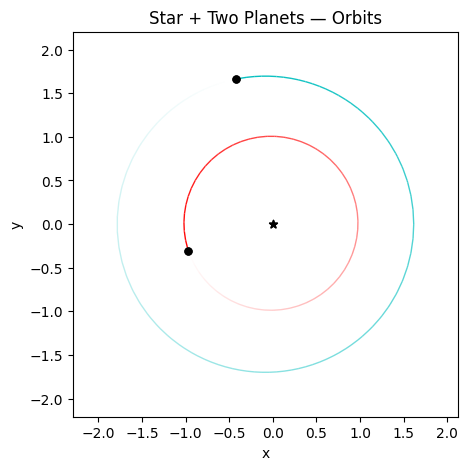

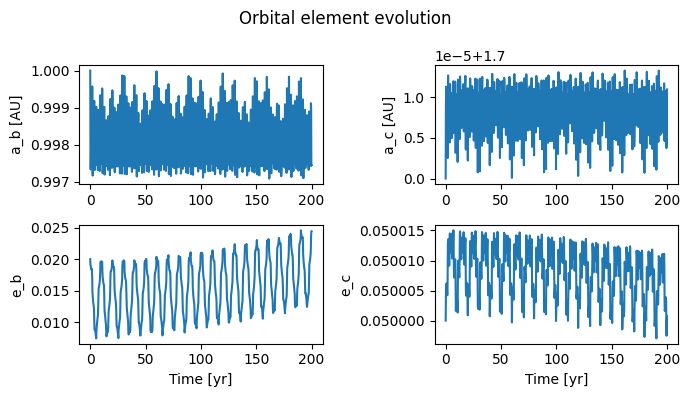

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

# Create a new simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add star and two planets
sim.add(m=1.0)                    # star
sim.add(m=3e-6, a=1.0, e=0.02)     # planet b (~Earth-mass)
sim.add(m=1e-3, a=1.7, e=0.05)     # planet c (~Jupiter-mass)
sim.move_to_com()

# Integrate and record orbital elements
times = np.linspace(0, 200, 1000)
a_b, e_b, a_c, e_c = [], [], [], []

for t in times:
    sim.integrate(t)
    orbits = sim.orbits()
    a_b.append(orbits[0].a); e_b.append(orbits[0].e)
    a_c.append(orbits[1].a); e_c.append(orbits[1].e)

# Plot the orbits in the x–y plane
fig = rebound.OrbitPlot(sim, color=True)
plt.title("Star + Two Planets — Orbits")
plt.show()

# Plot orbital elements vs time
plt.figure(figsize=(7,4))
plt.subplot(2,2,1); plt.plot(times, a_b); plt.ylabel('a_b [AU]')
plt.subplot(2,2,2); plt.plot(times, a_c); plt.ylabel('a_c [AU]')
plt.subplot(2,2,3); plt.plot(times, e_b); plt.xlabel('Time [yr]'); plt.ylabel('e_b')
plt.subplot(2,2,4); plt.plot(times, e_c); plt.xlabel('Time [yr]'); plt.ylabel('e_c')
plt.suptitle('Orbital element evolution')
plt.tight_layout(); plt.show()


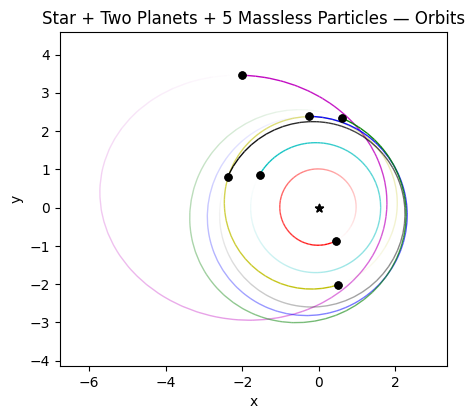

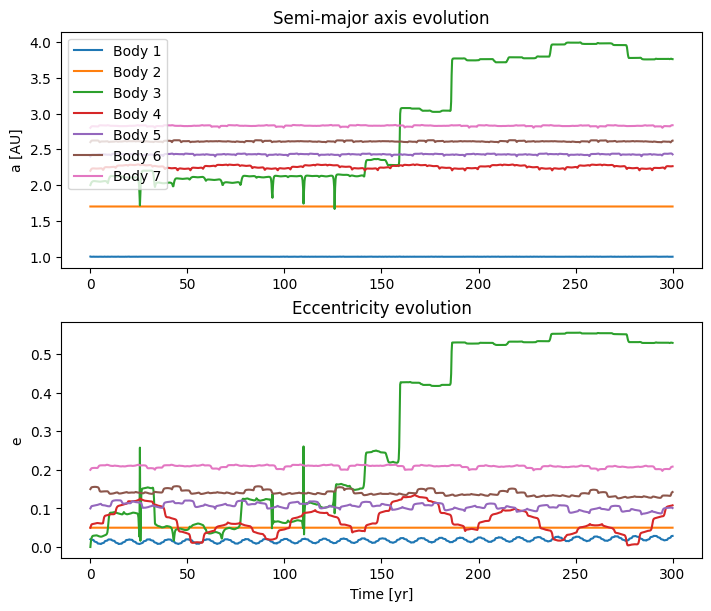

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

# Create a new simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add star and two planets
sim.add(m=1.0)                    
sim.add(m=3e-6, a=1.0, e=0.02)     
sim.add(m=1e-3, a=1.7, e=0.05)     

# Add 5 massless particles
for i in range(5):
    sim.add(m=0.0, a=2.0 + 0.2*i, e=0.05*i)

sim.move_to_com()

# Integrate and record orbital elements
times = np.linspace(0, 300, 1200)
a_all = [[] for _ in range(sim.N-1)]
e_all = [[] for _ in range(sim.N-1)]

for t in times:
    sim.integrate(t)
    for i, o in enumerate(sim.orbits()):
        a_all[i].append(o.a)
        e_all[i].append(o.e)

# Plot the orbits in the x–y plane
fig = rebound.OrbitPlot(sim, color=True)
plt.title("Star + Two Planets + 5 Massless Particles — Orbits")
plt.show()

# Plot semi-major axis and eccentricity vs time
fig, axs = plt.subplots(2, 1, figsize=(7,6), constrained_layout=True)

for i in range(len(a_all)):
    axs[0].plot(times, a_all[i], label=f'Body {i+1}')
    axs[1].plot(times, e_all[i], label=f'Body {i+1}')

axs[0].set_ylabel('a [AU]')
axs[1].set_ylabel('e')
axs[1].set_xlabel('Time [yr]')
axs[0].set_title('Semi-major axis evolution')
axs[1].set_title('Eccentricity evolution')
axs[0].legend()
plt.show()


## From “messy” element evolution to chaos indicators

In the last plots, some bodies show wandering semi-major axes and eccentricities. That can happen for two main reasons:

1) **Numerical artifacts** — e.g., timestep too large for a symplectic method, or insufficient runtime to average out short-term oscillations.  
2) **Genuine dynamical complexity** — resonance overlap and strong perturbations can make trajectories **chaotic**, i.e., exponentially sensitive to tiny changes in initial conditions.

To **distinguish quasi-periodic (regular)** behavior from **chaotic** behavior, we use **chaos indicators**. A standard choice is **MEGNO** (Mean Exponential Growth factor of Nearby Orbits):

- For **regular** motion, the time-averaged MEGNO tends toward ~**2**.  
- For **chaotic** motion, MEGNO **grows above 2**.

In practice, we (i) keep a physically sensible integrator and step size, (ii) integrate long enough to avoid transient misclassification, and (iii) compute MEGNO to quantify the behavior.

Next, we’ll add a short MEGNO run to our current setup and inspect whether the dynamics are regular or chaotic.


## Stability map with MEGNO (two massive planets, WHFast)

We map dynamical behavior by scanning the outer planet’s initial semi-major axis \(a_c\) and eccentricity \(e_c\).  
For each grid point we integrate with WHFast and record **MEGNO**.

We use REBOUND’s built-in chaos tools (`sim.init_megno(...)`, `sim.calculate_megno()`), as in the REBOUND tutorial:
https://rebound.readthedocs.io/en/latest/ipython_examples/Megno/


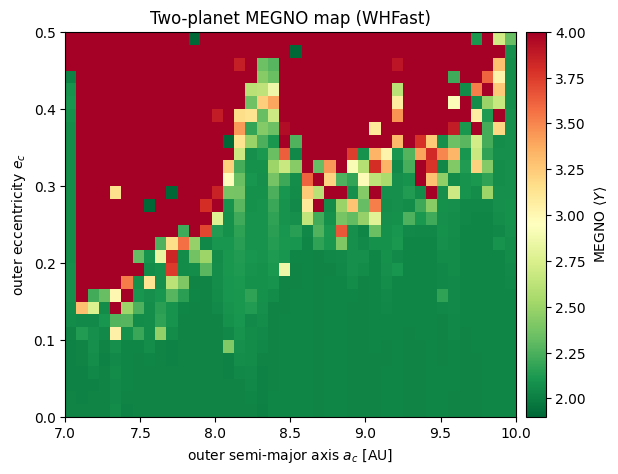

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

# ----- grid over outer planet's (a, e)
N_a, N_e = 40, 30
a_vals = np.linspace(7.0, 10.0, N_a)      # AU
e_vals = np.linspace(0.0,  0.50, N_e)

# ----- integration controls
tmax = 500.0              # years to integrate each grid point (increase for more robust classification)
dt   = 0.025               # years; small fraction of the shortest orbital period
exit_max_distance = 20.0  # AU; if a body escapes, we mark as strongly chaotic
megno_if_escape    = 10.0 # large MEGNO value on escape

Y = np.full((N_a, N_e), np.nan)

for ia, a_c in enumerate(a_vals):
    for je, e_c in enumerate(e_vals):
        # Build sim: Star + Jupiter-like + scanned planet (Saturn-like mass)
        sim = rebound.Simulation()
        sim.units = ('AU', 'yr', 'Msun')
        sim.integrator = "whfast"
        sim.ri_whfast.safe_mode = 0
        sim.dt = dt

        sim.add(m=1.0)                                   # star
        sim.add(m=0.000954, a=5.204, e=0.048, M=0.600, omega=0.257)   # Jupiter-like (fixed)
        sim.add(m=0.000285, a=a_c,   e=e_c,   M=0.871, omega=1.616)   # Saturn-like (scanned)

        sim.move_to_com()
        sim.exit_max_distance = exit_max_distance

        # Initialize chaos indicator (fixed seed for reproducibility)
        sim.init_megno(seed=0)

        try:
            # Integrate to tmax; exact_finish_time=0 preserves WHFast's fixed-step nature
            sim.integrate(tmax, exact_finish_time=0)
            # MEGNO accessor: prefer calculate_megno(); fall back to megno() if needed
            try:
                Y[ia, je] = sim.calculate_megno()
            except AttributeError:
                Y[ia, je] = sim.megno()
        except rebound.Escape:
            Y[ia, je] = megno_if_escape

# ----- plot MEGNO map
fig = plt.figure(figsize=(7,5))
extent = [a_vals.min(), a_vals.max(), e_vals.min(), e_vals.max()]
im = plt.imshow(
    Y.T, origin='lower', aspect='auto', extent=extent,
    vmin=1.9, vmax=4.0, cmap="RdYlGn_r"
)
plt.xlabel(r"outer semi-major axis $a_c$ [AU]")
plt.ylabel(r"outer eccentricity $e_c$")
cbar = plt.colorbar(im, pad=0.02)
cbar.set_label(r"MEGNO $\langle Y \rangle$")
plt.title("Two-planet MEGNO map (WHFast)")
plt.show()


## Interpreting the MEGNO map

This plot shows the MEGNO value of the system as a function of the outer planet’s initial semi-major axis \(a_c\) (x-axis) and eccentricity \(e_c\) (y-axis).

- **Green region (MEGNO ≈ 2):**  
  These are **regular, stable configurations**. Nearby orbits stay close together over time, and the dynamics are quasi-periodic.

- **Yellow to red regions (MEGNO > 2):**  
  These are **chaotic configurations**. Small changes in initial conditions grow exponentially, leading to diverging trajectories.

- **Pattern:**  
  The transition from stable (green) to chaotic (red) occurs mostly at **higher eccentricities**, and also along **narrow diagonal bands**.  
  These bands mark **mean-motion resonances** where gravitational interactions strongly perturb the orbits, triggering chaos.

- **Interpretation:**  
  Stable orbits are mostly confined to **low-eccentricity** regions, while **chaotic behavior dominates at higher \(e_c\)** or near resonance crossings.


## Modeling Observables: Radial Velocities

So far, we have tracked orbital elements, which describe the system internally.  
But we detect planets through **measurable quantities**, like:

- **Radial velocity (RV):** line-of-sight velocity of the star, measured via Doppler shifts.
- **Transits / light curves:** dips in stellar brightness when a planet crosses in front (not covered here).

We can compute the RV of the star as the **line-of-sight (z-axis) velocity** of the star relative to the system’s barycenter:

$$
v_\mathrm{rad}(t) = v_{x,\mathrm{star}}(t) - v_{x,\mathrm{bary}}(t)
$$

Assuming the observer looks along the x axis (an edge-on system), this gives a simple synthetic RV curve.


## Example: Radial Velocity of the Sun induced by Earth, Jupiter, and Saturn

We now simulate a simple real system: **Earth, Jupiter, and Saturn orbiting the Sun**.  
As these planets orbit, they pull the Sun around the system barycenter, producing a combined radial-velocity (RV) signal.

Assumptions (coplanar, default angles):
- Sun mass = $1.0\,M_\odot$
- Earth mass = $3.0\times10^{-6}\,M_\odot$, $a=1.0\,\mathrm{AU}$, $e=0.0167$
- Jupiter mass = $0.000954\,M_\odot$, $a=5.2\,\mathrm{AU}$, $e=0.048$
- Saturn mass = $0.000285\,M_\odot$, $a=9.58\,\mathrm{AU}$, $e=0.0565$

We measure the Sun’s line-of-sight velocity along the x axis.


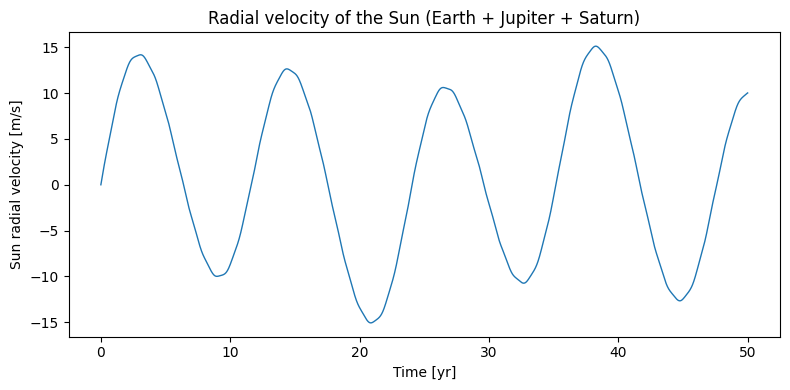

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

# Sun–Earth–Jupiter–Saturn RV simulation
sim = rebound.Simulation()
sim.units = ('AU','yr','Msun')
sim.integrator = 'whfast'
sim.dt = 0.002

# Bodies
sim.add(m=1.0)                                  # Sun
sim.add(m=3.0e-6,   a=1.0,   e=0.0167)          # Earth
sim.add(m=0.000954, a=5.2,   e=0.048)           # Jupiter
sim.add(m=0.000285, a=9.58,  e=0.0565)          # Saturn
sim.move_to_com()

# Integrate and record Sun's RV (vz)
T_end = 50.0                     # years
N = 4000
times = np.linspace(0, T_end, N)
rv_kms = []

for t in times:
    sim.integrate(t)
    sun = sim.particles[0]
    rv_kms.append(sun.vx * 4.74047 * 1000)   # AU/yr → m/s

# Plot
plt.figure(figsize=(8,4))
plt.plot(times, rv_kms, lw=1)
plt.xlabel('Time [yr]')
plt.ylabel('Sun radial velocity [m/s]')
plt.title('Radial velocity of the Sun (Earth + Jupiter + Saturn)')
plt.tight_layout()
plt.show()


## Saving and Loading Simulations

For longer or repeated runs, REBOUND lets you save simulations using `SimulationArchive`.

- It stores the full state of the simulation (positions, velocities, masses, etc.) at multiple times.
- You can later load the archive, inspect it, or continue the simulation.

This is useful for:
- Avoiding recomputation in long runs
- Comparing system states at different times
- Sharing exact simulation setups with others


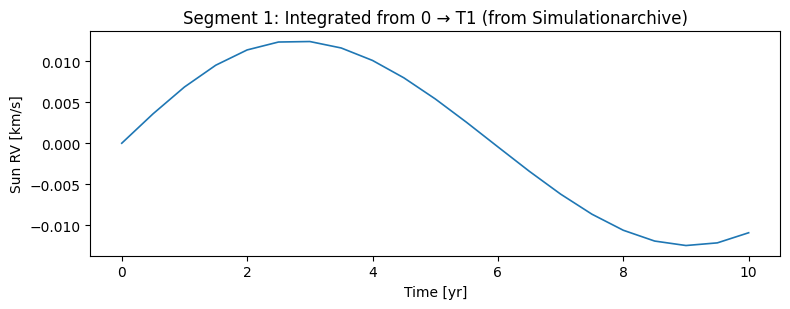

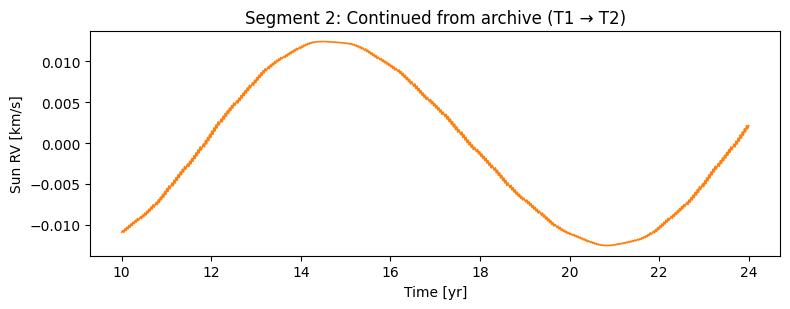

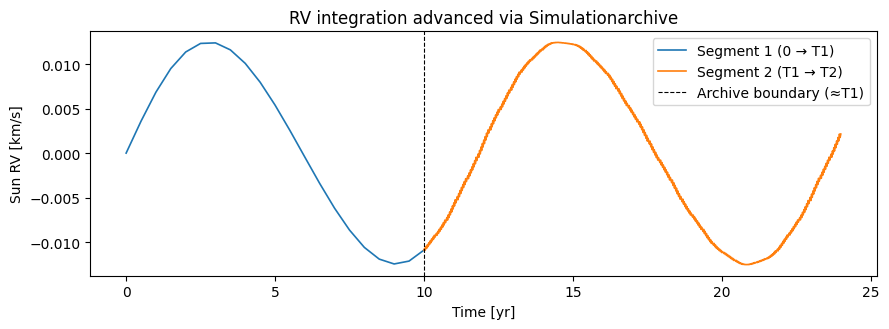

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import rebound

# ---------------------------------------------
# 1) Build system, configure integrator, enable archive snapshots
# ---------------------------------------------
sim = rebound.Simulation()
sim.units = ('AU','yr','Msun')

# Star + two planets (inner sets the timestep scale)
sim.add(m=1.0)                     # star
sim.add(m=3.0e-6, a=1.0, e=0.0167) # Earth-like (inner)
sim.add(m=9.54e-4, a=5.2, e=0.048) # Jupiter-like (outer)
sim.move_to_com()

# WHFast, timestep ~5% of inner orbital period (per docs)
sim.integrator = "whfast"
sim.dt = sim.particles[1].P * 0.05

# Save snapshots every 0.5 yr; overwrite if file exists
archive_path = "archive.bin"
sim.save_to_file(archive_path, interval=0.5, delete_file=True)

# First integration segment (e.g., 12 years)
T1 = 10.0
sim.integrate(T1)  # snapshots written automatically during the run

# ---------------------------------------------
# 2) Read back the first segment from the archive and plot an observable
#    (Sun's radial velocity along x here)
# ---------------------------------------------
sa = rebound.Simulationarchive(archive_path)  # NOTE: 'Simulationarchive' (lowercase 'a')

# Extract times and Sun's RV from snapshots
times1 = [s.t for s in sa]                     # all snapshot times (0 .. T1)
rv1    = [s.particles[0].vx * 4.74047 for s in sa]   # AU/yr -> km/s

plt.figure(figsize=(8,3.2))
plt.plot(times1, rv1, lw=1.2)
plt.xlabel("Time [yr]")
plt.ylabel("Sun RV [km/s]")
plt.title("Segment 1: Integrated from 0 → T1 (from Simulationarchive)")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 3) Load the last snapshot, continue integrating further, and plot
# ---------------------------------------------
sim2 = sa[-1]                 # restore simulation at the last archived time (~T1)
# (The archive stores integrator and dt; we keep WHFast and the same dt. Being explicit is fine:)
sim2.integrator = "whfast"
sim2.dt = sim.dt

# Continue to T2 > T1
T2 = 24.0
# Choose output times for the continuation plot
times2 = np.linspace(sim2.t, T2, 600)
rv2 = []
for t in times2:
    # For WHFast, exact_finish_time=0 keeps fixed-step behavior (good practice when sampling)
    sim2.integrate(t, exact_finish_time=0)
    rv2.append(sim2.particles[0].vx * 4.74047)  # AU/yr -> km/s

plt.figure(figsize=(8,3.2))
plt.plot(times2, rv2, lw=1.2, color="C1")
plt.xlabel("Time [yr]")
plt.ylabel("Sun RV [km/s]")
plt.title("Segment 2: Continued from archive (T1 → T2)")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 4) Optional combined view to emphasize advancement across the archive boundary
# ---------------------------------------------
plt.figure(figsize=(9,3.4))
plt.plot(times1, rv1, lw=1.2, label="Segment 1 (0 → T1)")
plt.plot(times2, rv2, lw=1.2, label="Segment 2 (T1 → T2)", color="C1")
plt.axvline(times1[-1], ls='--', color='k', lw=0.8, label="Archive boundary (≈T1)")
plt.xlabel("Time [yr]")
plt.ylabel("Sun RV [km/s]")
plt.title("RV integration advanced via Simulationarchive")
plt.legend()
plt.tight_layout()
plt.show()


## Further Reading

- **REBOUND documentation:**  
  [https://rebound.readthedocs.io](https://rebound.readthedocs.io)  
  Full API reference, tutorials, and example notebooks.

- **Chaos indicators (MEGNO, LCN):**  
  [https://rebound.readthedocs.io/en/latest/chaos/](https://rebound.readthedocs.io/en/latest/chaos/)  
  Theory and implementation details for detecting chaotic dynamics.

- **SimulationArchive:**  
  [https://rebound.readthedocs.io/en/latest/ipython_examples/Simulationarchive/](https://rebound.readthedocs.io/en/latest/ipython_examples/Simulationarchive/)  
  Efficient long-term storage and reloading of simulations.

- **REBOUND Papers:**  
[https://rebound.readthedocs.io/en/latest/#papers](https://rebound.readthedocs.io/en/latest/#papers)


## References & Credits
- **REBOUND:** Rein & Liu (2012), Rein & Spiegel (2015)
- **Integrators:** `ias15` (high-accuracy), `whfast` (symplectic, Wisdom–Holman)  
- **Author:** Ekrem M. Esmer (ExoCore N-Body Dynamics module)

If you use or adapt this notebook, please credit the ExoCore project and the author.
